In [158]:
import pandas as pd

In [159]:
csv_path = "../data/custom/orders.csv"
raw_csv_path = "../data/csv/Hackaton/Detalle_entrega.csv"
df = pd.read_csv(csv_path)

transport_col = "transport_id"
client_col = "client"
date_col = "date"
amount_col = "amount"
item_col = "item"
item_description_col = "item_description"
unit_col = "unit"

required_columns = {
    transport_col,
    client_col,
    date_col,
    amount_col,
    item_col,
    item_description_col,
    unit_col,
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in cleaned dataset: {sorted(missing_columns)}")

# Cleaned file can sometimes contain one client per transport_id,
# which collapses client co-occurrence graphs. In that case, recover
# route-level client identity from the raw dataset while keeping cleaned rows.
unique_clients_per_transport = df.groupby(transport_col)[client_col].nunique(dropna=True)
needs_client_recovery = (
    not unique_clients_per_transport.empty
    and unique_clients_per_transport.max() <= 1
)

if needs_client_recovery:
    raw_columns = [
        "FECHA",
        "Transporte",
        "Destinatario mcía.",
        "Nombre 1",
        "Material",
        "Cantidad entrega",
        "Un.medida venta",
    ]
    raw_df = pd.read_csv(raw_csv_path, usecols=raw_columns).rename(
        columns={
            "FECHA": date_col,
            "Transporte": transport_col,
            "Destinatario mcía.": "client_id",
            "Nombre 1": "client_name",
            "Material": item_col,
            "Cantidad entrega": amount_col,
            "Un.medida venta": unit_col,
        }
    )

    raw_df[unit_col] = raw_df[unit_col].astype(str).str.strip().str.lower()

    raw_df[amount_col] = pd.to_numeric(raw_df[amount_col], errors="coerce")
    raw_df = raw_df[raw_df[amount_col].notna()].copy()

    df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")

    merge_cols = [date_col, transport_col, item_col, amount_col, unit_col]
    for col in [date_col, transport_col, item_col, unit_col]:
        df[col] = df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].astype(str).str.strip()

    df["_match_seq"] = df.groupby(merge_cols).cumcount()
    raw_df["_match_seq"] = raw_df.groupby(merge_cols).cumcount()

    df = df.merge(
        raw_df[merge_cols + ["_match_seq", "client_id", "client_name"]],
        on=merge_cols + ["_match_seq"],
        how="left",
    )
    df = df.drop(columns=["_match_seq"])

    df["analysis_client"] = (
        df["client_name"].fillna(df["client_id"]).fillna(df[client_col]).astype(str).str.strip()
    )
    print("Recovered client identity from raw dataset for clustering analysis.")
else:
    df["analysis_client"] = df[client_col].astype(str).str.strip()

client_col = "analysis_client"

In [160]:
unique_transport_ids = sorted(df[transport_col].dropna().unique())

for transport_id in unique_transport_ids:
    df_transport = df[df[transport_col] == transport_id]

    unique_clients = sorted(df_transport[client_col].dropna().astype(str).unique())

    print(
        f"transport_id={transport_id} rows={len(df_transport)} unique_clients={len(unique_clients)}"
    )
    # Uncomment this line to see all unique client names for each transport id.
    # print(unique_clients)



transport_id=11420136 rows=3 unique_clients=1
transport_id=11420324 rows=3 unique_clients=2
transport_id=11420325 rows=7 unique_clients=1
transport_id=11420326 rows=9 unique_clients=1
transport_id=11420327 rows=7 unique_clients=1
transport_id=11420328 rows=66 unique_clients=4
transport_id=11420329 rows=65 unique_clients=4
transport_id=11420330 rows=5 unique_clients=1
transport_id=11420331 rows=24 unique_clients=3
transport_id=11420332 rows=54 unique_clients=6
transport_id=11420334 rows=24 unique_clients=5
transport_id=11420379 rows=53 unique_clients=8
transport_id=11420391 rows=14 unique_clients=3
transport_id=11420392 rows=6 unique_clients=1
transport_id=11420393 rows=134 unique_clients=14
transport_id=11420414 rows=64 unique_clients=9
transport_id=11420415 rows=117 unique_clients=3
transport_id=11420416 rows=125 unique_clients=9
transport_id=11420417 rows=32 unique_clients=6
transport_id=11420461 rows=117 unique_clients=13
transport_id=11420516 rows=2 unique_clients=1
transport_id=11

In [161]:
from collections import Counter
from itertools import combinations

# Count how often each pair of clients appears together in the same transport_id.
pair_counts = Counter()

for transport_id, df_transport in df.groupby(transport_col):
    clients = sorted(df_transport[client_col].dropna().astype(str).unique())

    # Only transport_ids with at least 2 unique clients can generate a pair.
    if len(clients) < 2:
        continue

    for pair in combinations(clients, 2):
        pair_counts[pair] += 1

pairs_df = (
    pd.DataFrame(
        [(c1, c2, cnt) for (c1, c2), cnt in pair_counts.items()],
        columns=["client_1", "client_2", "times_together"],
    )
    .sort_values("times_together", ascending=False)
    .reset_index(drop=True)
)

clients_with_company = set(pairs_df["client_1"]).union(set(pairs_df["client_2"]))

print(f"Clients delivered together with at least one other client: {len(clients_with_company)}")
print(f"Unique client pairs found: {len(pairs_df)}")
print(f"Total co-occurrence events: {pairs_df['times_together'].sum()}")

pairs_df.head(20)

Clients delivered together with at least one other client: 1171
Unique client pairs found: 24145
Total co-occurrence events: 48872


,client_1,client_2,times_together
0,CAFE DE LA CORONA,PA TONET,17
1,BONATAPA,Bar 20 PA K,17
2,BAR DE LA BENZINERA,BAR DE LA BENZINERA HIGIENE,17
3,BRUNCH 4.12 MUSIC,CAFETERIA ANGELA,17
4,RESTAURANT NOU PAMPLONA,RESTAURANT NOU PAMPLONA HIGIENE,16
5,BAR LOS GALLEGOS,LA PERGOLA,16
6,CAFE SANT ROC,PA TONET,16
7,CAFE DE LA CORONA,PURE COFFEE,16
8,CAFE DE LA CORONA,CAFE SANT ROC,16
9,BAR RESTAURANT PAVEPIC,BAR XARANA GRANOLLERS,15


In [162]:
# Count the most frequent clients and keep only top-X for clustering.
# Frequency here is based on delivery rows in the dataset.
top_x_clients = 500

client_frequency = (
    df[client_col].dropna().astype(str).value_counts().rename("deliveries")
)

top_clients = set(client_frequency.head(top_x_clients).index)

filtered_pairs_df = pairs_df[
    pairs_df["client_1"].isin(top_clients) & pairs_df["client_2"].isin(top_clients)
].copy()

print(f"Total unique clients: {client_frequency.shape[0]}")
print(f"Top-X selected clients: {len(top_clients)}")
print(f"Pairs kept after top-X filter: {len(filtered_pairs_df)}")

client_frequency.head(20)

Total unique clients: 1184
Top-X selected clients: 500
Pairs kept after top-X filter: 8175


analysis_client
RESTAURANT NOU PAMPLONA                808
CAFE DE LA CORONA                      530
La Sala                                474
PITAPES CALDERI 3 BRANQUES VALLES ,    471
412 COFFEE BEER                        415
CASA FONDA EUROPA                      395
LLEVANTPARK SL                         394
CULTURAL LA FABRICA                    393
BAR RESTAURANT LA PLAÇA                372
BRUNCH 4.12 MUSIC                      371
CAFE SANT ROC                          357
MESON 20 P KA                          345
BAR CAFETERIA EL TAST                  334
LA PLANCHA ÑAM ÑAM                     328
PEPE.COM                               326
BAR RESTAURANTE MERLY´S                324
VERMUTERIA Y TAPERIA CAMACHO           320
CANTABRIA RESTAURANT                   315
BONATAPA                               296
BAR DE LA BENZINERA                    290
Name: deliveries, dtype: int64

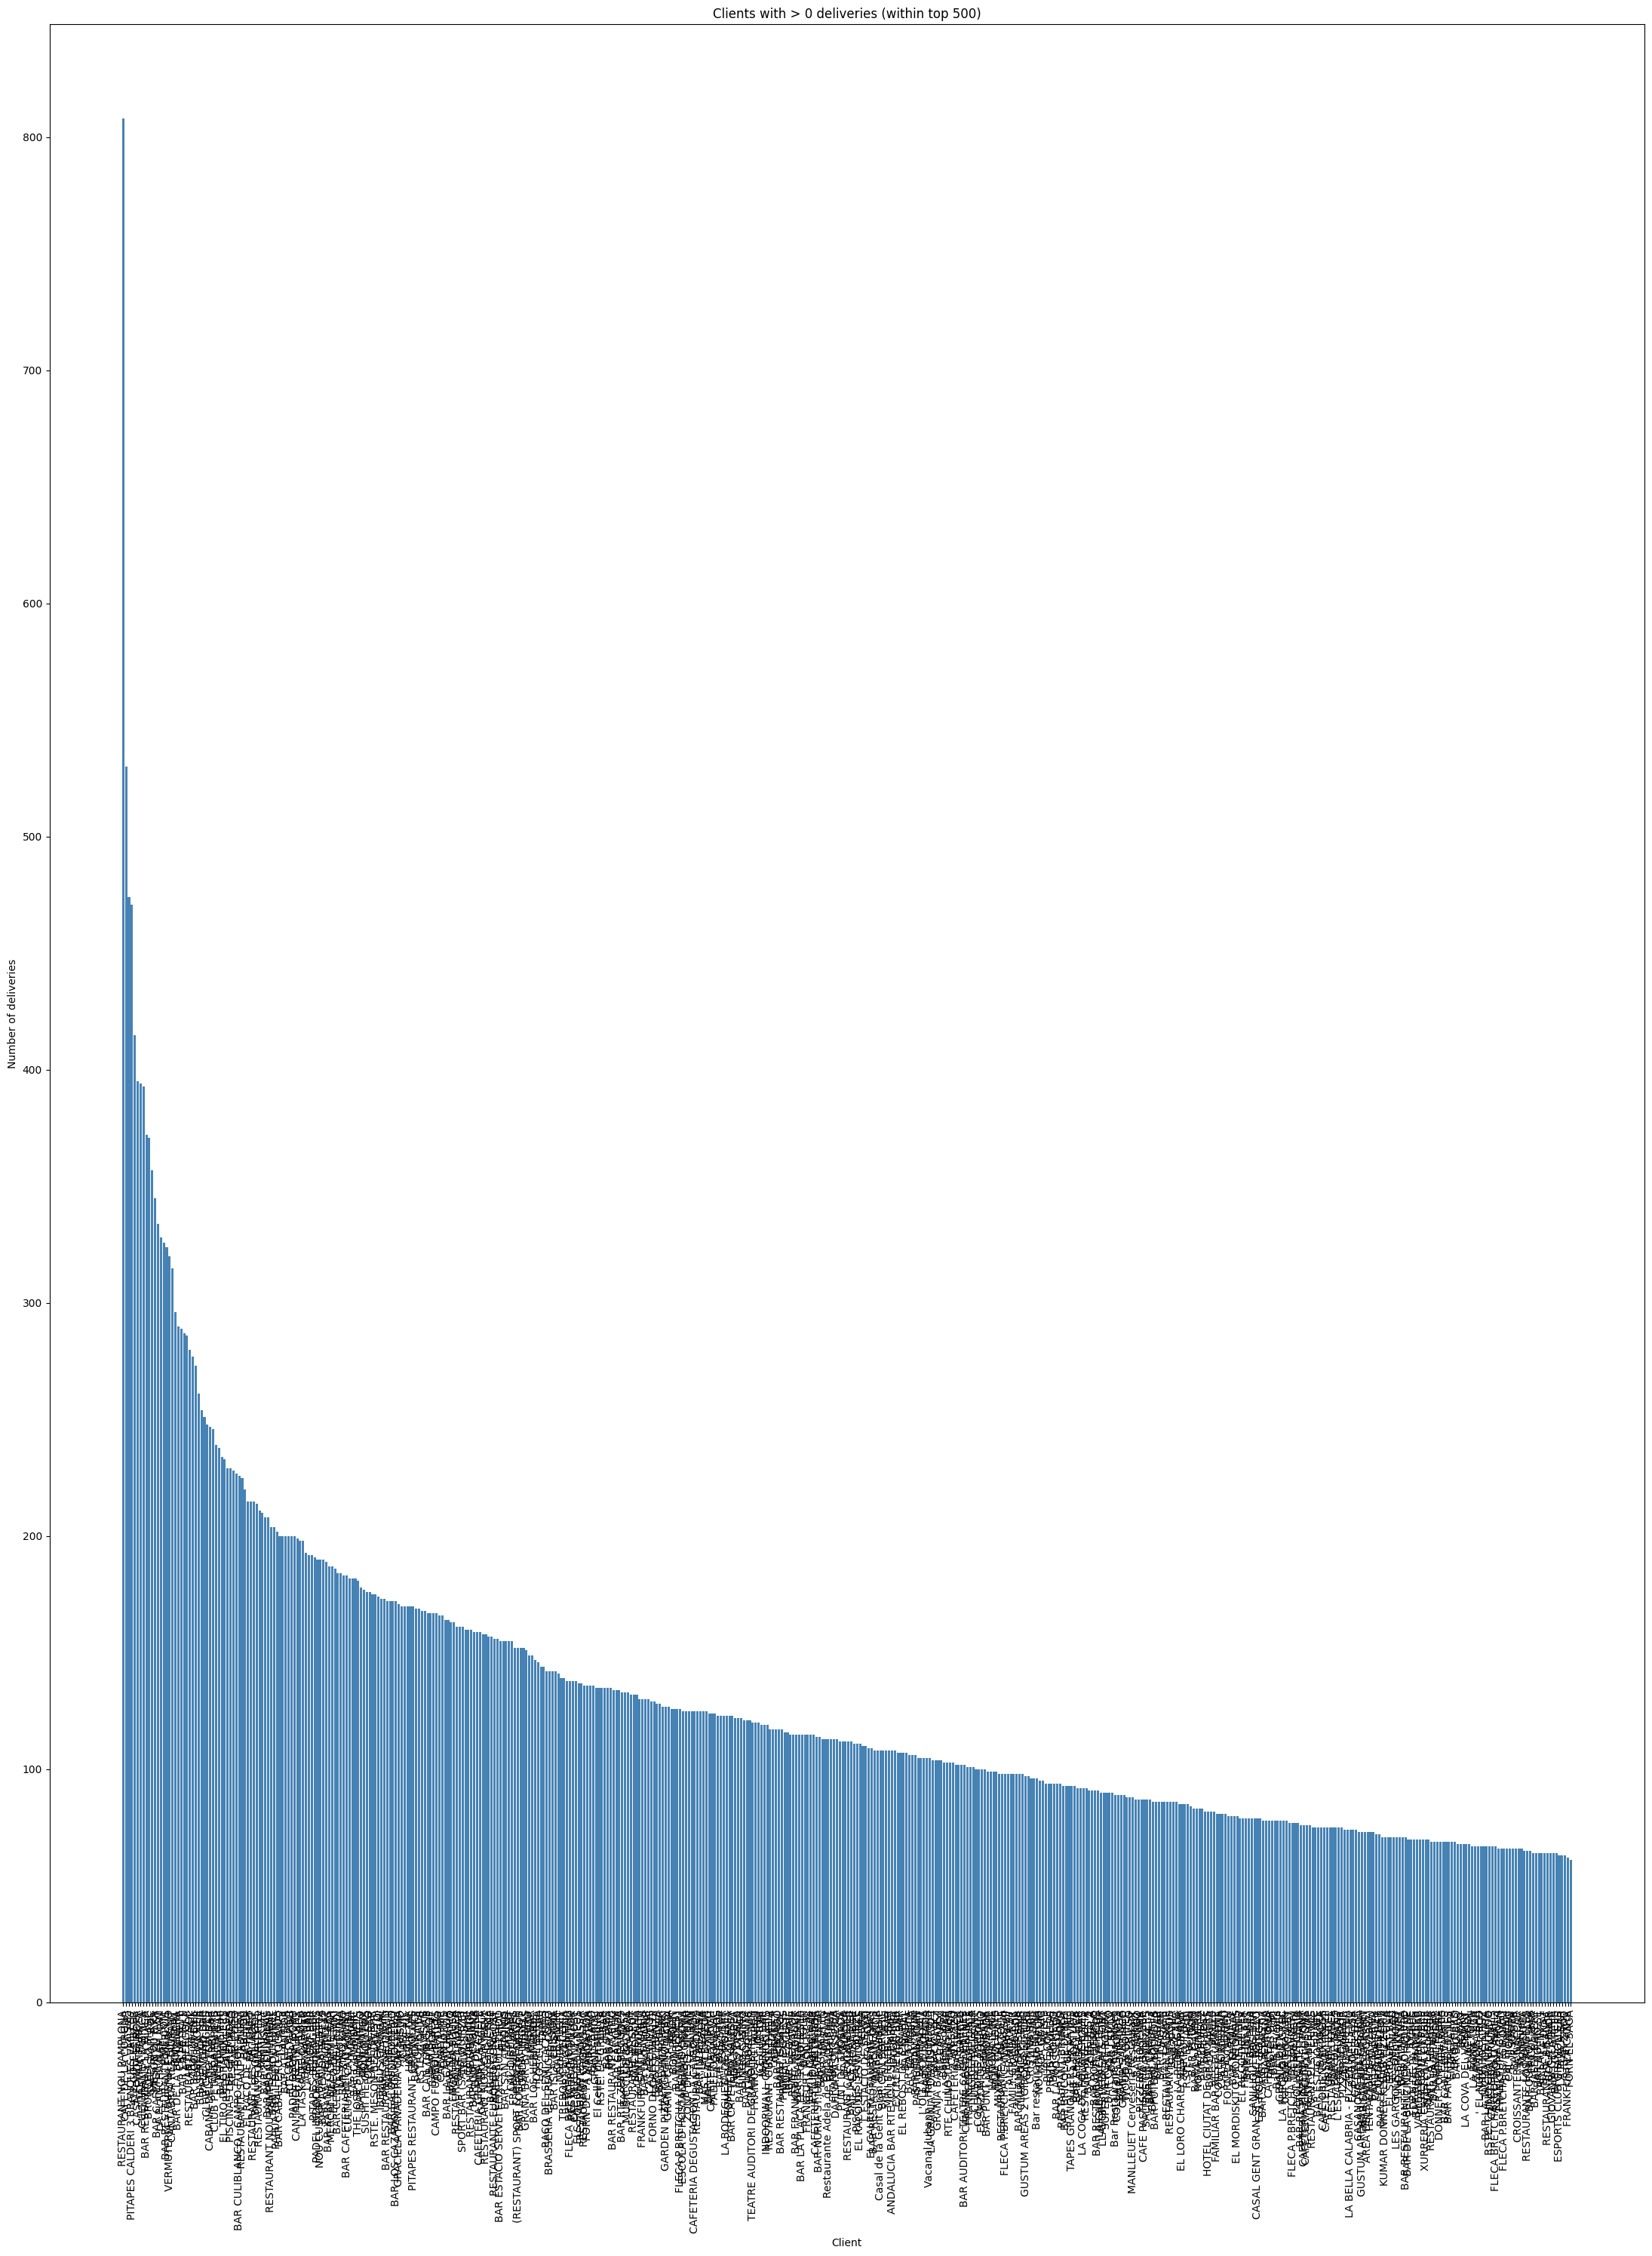

Pairs kept after top-X filter: 33.86%


In [163]:
import matplotlib.pyplot as plt

# Visualize frequent clients with client names on x-axis.
plot_n_clients = min(500, len(client_frequency))
min_deliveries_for_plot = 0

top_clients_plot = (
    client_frequency.head(plot_n_clients)
    .loc[lambda s: s > min_deliveries_for_plot]
    .sort_values(ascending=False)
)

plt.figure(figsize=(22, 30))
plt.bar(top_clients_plot.index, top_clients_plot.values, color="steelblue")
plt.title(
    f"Clients with > {min_deliveries_for_plot} deliveries (within top {plot_n_clients})"
)
plt.xlabel("Client")
plt.ylabel("Number of deliveries")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()

# Optional quick context: how much data is retained by top-X filtering.
pairs_kept_pct = (len(filtered_pairs_df) / len(pairs_df) * 100) if len(pairs_df) else 0
print(f"Pairs kept after top-X filter: {pairs_kept_pct:.2f}%")

In [164]:
# Greedy clustering without cluster merges, using only filtered top-X clients.
# Rules:
# 1) If neither client is assigned -> create a new cluster with both.
# 2) If exactly one is assigned -> add the other to that same cluster.
# 3) If both are already assigned -> invalid pair, skip.
min_times_together = 1

pairs_for_clustering = filtered_pairs_df[
    filtered_pairs_df["times_together"] >= min_times_together
].copy()

clusters = []
client_to_cluster = {}
invalid_matches = 0

for _, row in pairs_for_clustering.iterrows():
    c1 = row["client_1"]
    c2 = row["client_2"]

    cluster_idx_1 = client_to_cluster.get(c1)
    cluster_idx_2 = client_to_cluster.get(c2)

    if cluster_idx_1 is None and cluster_idx_2 is None:
        new_cluster = {c1, c2}
        clusters.append(new_cluster)
        new_idx = len(clusters) - 1
        client_to_cluster[c1] = new_idx
        client_to_cluster[c2] = new_idx

    elif cluster_idx_1 is not None and cluster_idx_2 is None:
        clusters[cluster_idx_1].add(c2)
        client_to_cluster[c2] = cluster_idx_1

    elif cluster_idx_1 is None and cluster_idx_2 is not None:
        clusters[cluster_idx_2].add(c1)
        client_to_cluster[c1] = cluster_idx_2

    else:
        invalid_matches += 1

# Add singleton clusters only for selected top clients not assigned in accepted pairs.
clustered_clients = set().union(*clusters) if clusters else set()
for client in sorted(top_clients - clustered_clients):
    clusters.append({client})

cluster_rows = [
    {
        "cluster_id": idx,
        "cluster_size": len(cluster),
        "members": sorted(cluster),
    }
    for idx, cluster in enumerate(clusters)
]

clusters_df = (
    pd.DataFrame(cluster_rows)
    .sort_values(["cluster_size", "cluster_id"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Total clusters (top-X universe): {len(clusters_df)}")
print(f"Largest cluster size: {clusters_df['cluster_size'].max()}")
print(f"Singleton clusters: {(clusters_df['cluster_size'] == 1).sum()}")
print(f"Invalid matches skipped: {invalid_matches}")

clusters_df.head(60)

Total clusters (top-X universe): 87
Largest cluster size: 22
Singleton clusters: 1
Invalid matches skipped: 7762


,cluster_id,cluster_size,members
0,0,22,"[A VOCADOS, BAR LOCALET, BAR MERCADO, BINGO CA..."
1,2,14,"[BAR DE LA BENZINERA, BAR DE LA BENZINERA HIGI..."
2,11,13,"[BAR CAFETERIA KALESSY, BAR NEVADA II, BAR RES..."
3,21,13,"[BAR CAN BORRELL, BAR DE TAPES, BAR ESPERANZA,..."
4,32,13,"[AKI MISMO, BAR CAN CERVANTES, BAR KEBAR, BAR ..."
5,45,13,"[BAR BOTE, BAR EL GARAJE, BAR LINARES, BAR MAR..."
6,16,11,"[BAR ALMANSA, BAR CA LA XIANG, BAR EL DOFI, BR..."
7,1,10,"[BAR CERVECERIA JORDI, BAR COCO, BAR FUTBOL LO..."
8,3,10,"[412 COFFEE BEER, BRUNCH 4.12 MUSIC, CAFETERIA..."
9,8,10,"[BAR CA LA MARI, BAR LA GRANJA, BAR SERRA LLIÇ..."


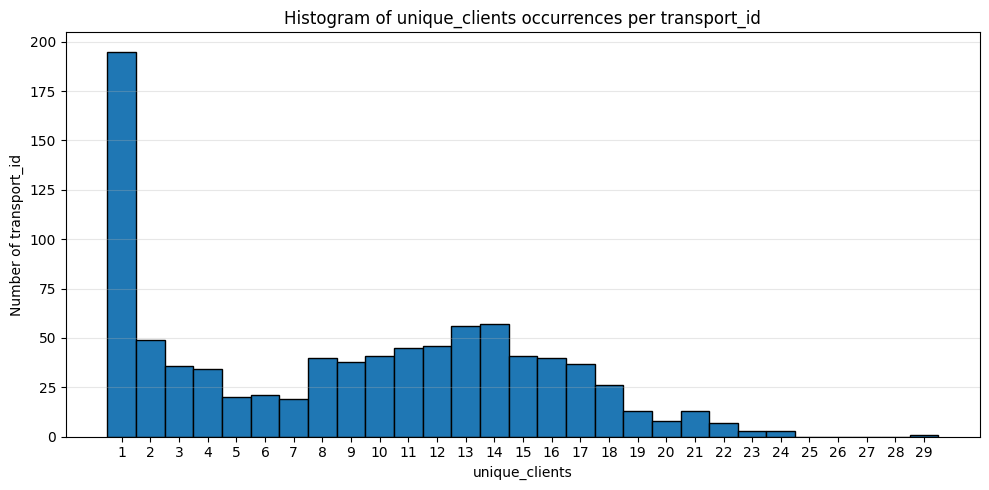

count    889.000000
mean       8.883015
std        6.322047
min        1.000000
25%        2.000000
50%        9.000000
75%       14.000000
max       29.000000
Name: unique_clients, dtype: float64

In [165]:
import matplotlib.pyplot as plt

# Number of unique clients per transport_id.
unique_clients_per_transport = (
    df.groupby(transport_col)[client_col]
    .nunique()
    .rename("unique_clients")
)

plt.figure(figsize=(10, 5))
plt.hist(
    unique_clients_per_transport,
    bins=range(1, unique_clients_per_transport.max() + 2),
    edgecolor="black",
    align="left",
)
plt.title("Histogram of unique_clients occurrences per transport_id")
plt.xlabel("unique_clients")
plt.ylabel("Number of transport_id")
plt.xticks(range(1, unique_clients_per_transport.max() + 1))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

unique_clients_per_transport.describe()

In [166]:
for cluster in clusters_df.iterrows():
    print(cluster)

(0, cluster_id                                                      0
cluster_size                                                   22
members         [A VOCADOS, BAR LOCALET, BAR MERCADO, BINGO CA...
Name: 0, dtype: object)
(1, cluster_id                                                      2
cluster_size                                                   14
members         [BAR DE LA BENZINERA, BAR DE LA BENZINERA HIGI...
Name: 1, dtype: object)
(2, cluster_id                                                     11
cluster_size                                                   13
members         [BAR CAFETERIA KALESSY, BAR NEVADA II, BAR RES...
Name: 2, dtype: object)
(3, cluster_id                                                     21
cluster_size                                                   13
members         [BAR CAN BORRELL, BAR DE TAPES, BAR ESPERANZA,...
Name: 3, dtype: object)
(4, cluster_id                                                     32
cluster_size              

In [ ]:
import html
import re
import unicodedata
from pathlib import Path

import folium

# Build a client -> address query map from the raw source used for geocoding.
address_cols = ["Nombre 1", "Calle", "CP", "Población"]
address_df = pd.read_csv(raw_csv_path, usecols=address_cols, dtype=str)


def normalize_text(value: object) -> str:
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    return " ".join(text.split())


address_df = address_df.rename(columns={"Nombre 1": "client_name", "Calle": "street", "CP": "cp", "Población": "city"})
for col in ["client_name", "street", "cp", "city"]:
    address_df[col] = address_df[col].fillna("").astype(str).str.strip()

address_df = address_df[(address_df["client_name"] != "") & (address_df["street"] != "") & (address_df["cp"] != "") & (address_df["city"] != "")].copy()
address_df["client_norm"] = address_df["client_name"].map(normalize_text)
address_df["query"] = address_df["street"] + ", " + address_df["cp"] + " " + address_df["city"] + ", Spain"

# Keep the most frequent query for each client name.
client_query_map = (
    address_df.groupby(["client_norm", "query"], as_index=False)
    .size()
    .sort_values(["client_norm", "size"], ascending=[True, False])
    .drop_duplicates(subset=["client_norm"])
    [["client_norm", "query"]]
)

# Expand cluster members and attach each member to its geocoded point.
members_df = (
    clusters_df[["cluster_id", "cluster_size", "members"]]
    .explode("members")
    .rename(columns={"members": "client_name"})
)
members_df["client_norm"] = members_df["client_name"].map(normalize_text)
members_df = members_df.merge(client_query_map, on="client_norm", how="left")

geo_candidate_paths = [
    Path("../data/custom/geo/geocoded_direcciones.csv"),
    Path("data/custom/geo/geocoded_direcciones.csv"),
    Path("../data/geocoded_direcciones.csv"),
    Path("data/geocoded_direcciones.csv"),
]
geo_csv_path = next((p for p in geo_candidate_paths if p.exists()), None)
if geo_csv_path is None:
    raise FileNotFoundError(
        "Could not find geocoded_direcciones.csv. Checked: "
        + ", ".join(str(p) for p in geo_candidate_paths)
    )

geo_df = pd.read_csv(geo_csv_path, engine="python", on_bad_lines="skip")
required_geo_cols = {"query", "lat", "lon"}
missing_geo_cols = required_geo_cols - set(geo_df.columns)
if missing_geo_cols:
    raise ValueError(f"Missing columns in {geo_csv_path}: {sorted(missing_geo_cols)}")

geo_df = geo_df.dropna(subset=["query", "lat", "lon"]).copy()
geo_df["lat"] = pd.to_numeric(geo_df["lat"], errors="coerce")
geo_df["lon"] = pd.to_numeric(geo_df["lon"], errors="coerce")
geo_df = geo_df.dropna(subset=["lat", "lon"])
geo_df["query_norm"] = geo_df["query"].fillna("").astype(str).map(normalize_text)
geo_df = geo_df.drop_duplicates(subset=["query_norm"])

members_df["query_norm"] = members_df["query"].fillna("").astype(str).map(normalize_text)
map_df = members_df.merge(
    geo_df[["query_norm", "lat", "lon"]],
    on="query_norm",
    how="left",
)

missing_geo = map_df["lat"].isna().sum()
map_df = map_df.dropna(subset=["lat", "lon"]).copy()
if map_df.empty:
    raise ValueError("No cluster members could be matched to geocoded coordinates.")

center_lat = map_df["lat"].median()
center_lon = map_df["lon"].median()

# Generate one highlighted HTML map per cluster and one global interactive map
# where each cluster can be toggled as its own strong-highlight layer.
cluster_sizes = (
    map_df.groupby("cluster_id")["client_name"]
    .count()
    .sort_values(ascending=False)
)
cluster_order = cluster_sizes.index.tolist()

output_dir = Path("cluster_maps")
output_dir.mkdir(parents=True, exist_ok=True)

# Assign each cluster its own color.
cluster_colors = [
    "#DC2626", "#2563EB", "#16A34A", "#D97706", "#7C3AED", "#0891B2",
    "#BE123C", "#4F46E5", "#0D9488", "#9333EA", "#CA8A04", "#EA580C",
    "#E11D48", "#1D4ED8", "#059669", "#B45309", "#6D28D9", "#0E7490",
    "#DB2777", "#6366F1", "#14B8A6", "#A855F7", "#EAB308", "#F97316",
]
color_for_cluster = {cid: cluster_colors[i % len(cluster_colors)] for i, cid in enumerate(cluster_order)}
map_df["color"] = map_df["cluster_id"].map(color_for_cluster)

# Global map: every cluster is its own layer, ALL visible, each toggleable.
global_center_lat = map_df["lat"].median()
global_center_lon = map_df["lon"].median()
all_clusters_map = folium.Map(
    location=[global_center_lat, global_center_lon],
    zoom_start=10,
    tiles="CartoDB Positron",
)

map_summaries = []
print(len(cluster_order))

for rank, cluster_id in enumerate(cluster_order):
    selected_df = map_df[map_df["cluster_id"] == cluster_id].copy()
    if selected_df.empty:
        continue

    cluster_color = color_for_cluster[cluster_id]
    n_members = len(selected_df)

    # Global map layer for this cluster -- visible by default, toggleable.
    global_layer = folium.FeatureGroup(
        name=f"Cluster {int(cluster_id)} ({n_members} pts)",
        show=True,
    ).add_to(all_clusters_map)

    # Per-cluster standalone HTML map.
    center_lat = selected_df["lat"].median()
    center_lon = selected_df["lon"].median()
    cluster_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles="CartoDB Positron",
    )

    other_df = map_df[map_df["cluster_id"] != cluster_id]
    other_layer = folium.FeatureGroup(name="Other clusters", show=True).add_to(cluster_map)
    for row in other_df.itertuples(index=False):
        other_color = color_for_cluster.get(row.cluster_id, "#9CA3AF")
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=3,
            weight=1,
            color=other_color,
            fill=True,
            fill_color=other_color,
            fill_opacity=0.25,
            opacity=0.4,
            tooltip=f"Cluster {int(row.cluster_id)}",
        ).add_to(other_layer)

    selected_layer = folium.FeatureGroup(
        name=f"Cluster {int(cluster_id)}",
        show=True,
    ).add_to(cluster_map)

    for row in selected_df.itertuples(index=False):
        popup_text = (
            f"Client: {html.escape(str(row.client_name))}<br>"
            f"Cluster ID: {int(row.cluster_id)}<br>"
            f"Cluster size: {int(row.cluster_size)}<br>"
            f"Address: {html.escape(str(row.query))}"
        )
        marker_kwargs = {
            "location": [row.lat, row.lon],
            "radius": 8,
            "weight": 2,
            "color": cluster_color,
            "fill": True,
            "fill_color": cluster_color,
            "fill_opacity": 0.85,
            "opacity": 1.0,
            "popup": folium.Popup(popup_text, max_width=420),
            "tooltip": f"{row.client_name} (cluster {int(cluster_id)})",
        }
        folium.CircleMarker(**marker_kwargs).add_to(selected_layer)
        folium.CircleMarker(**marker_kwargs).add_to(global_layer)

    folium.LayerControl(collapsed=False).add_to(cluster_map)
    output_path = output_dir / f"cluster_{int(cluster_id):03d}.html"
    cluster_map.save(output_path)

    map_summaries.append({
        "cluster_id": int(cluster_id),
        "cluster_size": n_members,
        "color": cluster_color,
        "output_path": str(output_path),
    })

folium.LayerControl(collapsed=False).add_to(all_clusters_map)
all_clusters_map.save(output_dir / "all_clusters_layers.html")

summary_df = pd.DataFrame(map_summaries).sort_values("cluster_size", ascending=False)

mapped_clusters = set(map_df["cluster_id"].dropna().tolist())
all_clusters = set(clusters_df["cluster_id"].dropna().tolist())
missing_clusters = sorted(all_clusters - mapped_clusters)

print(f"Cluster members total: {len(members_df):,}")
print(f"Mapped to coordinates: {len(map_df):,}")
print(f"Missing coordinates: {missing_geo:,}")
print(f"Clusters represented on map: {map_df['cluster_id'].nunique():,} / {len(all_clusters):,}")
print(f"Clusters without mapped coordinates: {len(missing_clusters):,}")
if missing_clusters:
    print(f"First missing cluster IDs: {missing_clusters[:15]}")
print(f"Generated standalone maps: {len(map_summaries):,}")
print(f"Combined layers map: {(output_dir / 'all_clusters_layers.html').resolve()}")
print(f"Output folder: {output_dir.resolve()}")

summary_df

all_clusters_map

Cluster members total: 500
Mapped to coordinates: 494
Missing coordinates: 6
Clusters represented on map: 86 / 87
Clusters without mapped coordinates: 1
First missing cluster IDs: [50]
Generated standalone maps: 86
Combined layers map: /Users/luka.papez/Code/personal/damm-hackathon/notebooks/cluster_maps/all_clusters_layers.html
Output folder: /Users/luka.papez/Code/personal/damm-hackathon/notebooks/cluster_maps
